# Лабораторная работа №5

# Кудабаева Эвита ИУ5-62Б

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

sns.set_style("whitegrid")

In [2]:
df = sns.load_dataset('titanic')
data = df.copy()

age_medians = data.groupby('pclass')['age'].median()
def fill_age(row):
    if pd.isnull(row['age']):
        return age_medians[row['pclass']]
    return row['age']
data['age'] = data.apply(fill_age, axis=1)

data['embarked'].fillna(data['embarked'].mode()[0], inplace=True)

cols_to_drop = ['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male']
data.drop(columns=[col for col in cols_to_drop if col in data.columns], inplace=True)

data = pd.get_dummies(data, columns=['sex', 'embarked'], drop_first=True)

bool_cols = data.select_dtypes(include=['bool']).columns
for col in bool_cols:
    data[col] = data[col].astype(int)

print(f"Размер данных: {data.shape}")
data.head()

Размер данных: (891, 10)


,survived,pclass,age,sibsp,parch,fare,alone,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,0,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0,0
2,1,3,26.0,0,0,7.9250,1,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,0,1
4,0,3,35.0,0,0,8.0500,1,1,0,1


In [3]:
y = data['survived']
X = data.drop('survived', axis=1)

print(f"Признаки X: {X.shape}")
print(f"Целевая переменная y: {y.shape}")
print(f"\nРаспределение классов:")
print(y.value_counts())
print(f"Выживших: {y.mean()*100:.1f}%")
print(f"Погибших: {(1-y.mean())*100:.1f}%")

Признаки X: (891, 9)
Целевая переменная y: (891,)

Распределение классов:
survived
0    549
1    342
Name: count, dtype: int64
Выживших: 38.4%
Погибших: 61.6%


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

X_train: (712, 9), X_test: (179, 9)
y_train: (712,), y_test: (179,)


In [5]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred_rf))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest
Accuracy: 0.8101
F1-score: 0.7463

Classification report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       110
           1       0.77      0.72      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179

Confusion matrix:
[[95 15]
 [19 50]]


In [6]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)
bagging.fit(X_train, y_train)

y_pred_bag = bagging.predict(X_test)

accuracy_bag = accuracy_score(y_test, y_pred_bag)
f1_bag = f1_score(y_test, y_pred_bag)

print("Bagging")
print(f"Accuracy: {accuracy_bag:.4f}")
print(f"F1-score: {f1_bag:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred_bag))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_bag))

Bagging
Accuracy: 0.8212
F1-score: 0.7576

Classification report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.79      0.72      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179

Confusion matrix:
[[97 13]
 [19 50]]


In [7]:
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)

accuracy_ada = accuracy_score(y_test, y_pred_ada)
f1_ada = f1_score(y_test, y_pred_ada)

print("AdaBoost")
print(f"Accuracy: {accuracy_ada:.4f}")
print(f"F1-score: {f1_ada:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred_ada))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_ada))

AdaBoost
Accuracy: 0.7821
F1-score: 0.6977

Classification report:
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       110
           1       0.75      0.65      0.70        69

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.76       179
weighted avg       0.78      0.78      0.78       179

Confusion matrix:
[[95 15]
 [24 45]]


In [8]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

accuracy_gb = accuracy_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)

print("Gradient Boosting")
print(f"Accuracy: {accuracy_gb:.4f}")
print(f"F1-score: {f1_gb:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred_gb))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_gb))

Gradient Boosting
Accuracy: 0.8045
F1-score: 0.7200

Classification report:
              precision    recall  f1-score   support

           0       0.80      0.90      0.85       110
           1       0.80      0.65      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179

Confusion matrix:
[[99 11]
 [24 45]]


Важность признаков в Random Forest:
      Признак  Важность
4        fare  0.279033
6    sex_male  0.260290
1         age  0.248351
0      pclass  0.087707
2       sibsp  0.041636
3       parch  0.032357
8  embarked_S  0.023586
5       alone  0.016451
7  embarked_Q  0.010589


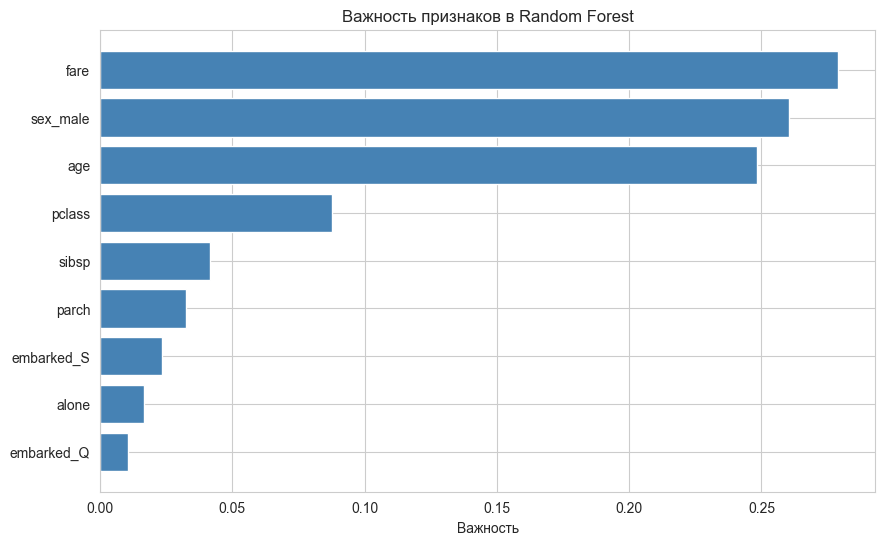

In [9]:
feature_importance = pd.DataFrame({
    'Признак': X.columns,
    'Важность': rf.feature_importances_
}).sort_values('Важность', ascending=False)

print("Важность признаков в Random Forest:")
print(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Признак'], feature_importance['Важность'], color='steelblue')
plt.xlabel('Важность')
plt.title('Важность признаков в Random Forest')
plt.gca().invert_yaxis()
plt.show()

Сравнение моделей:
              Модель  Accuracy  F1-score
0      Random Forest    0.8101    0.7463
1            Bagging    0.8212    0.7576
2           AdaBoost    0.7821    0.6977
3  Gradient Boosting    0.8045    0.7200

Лучшая модель по F1-score: Bagging (0.7576)


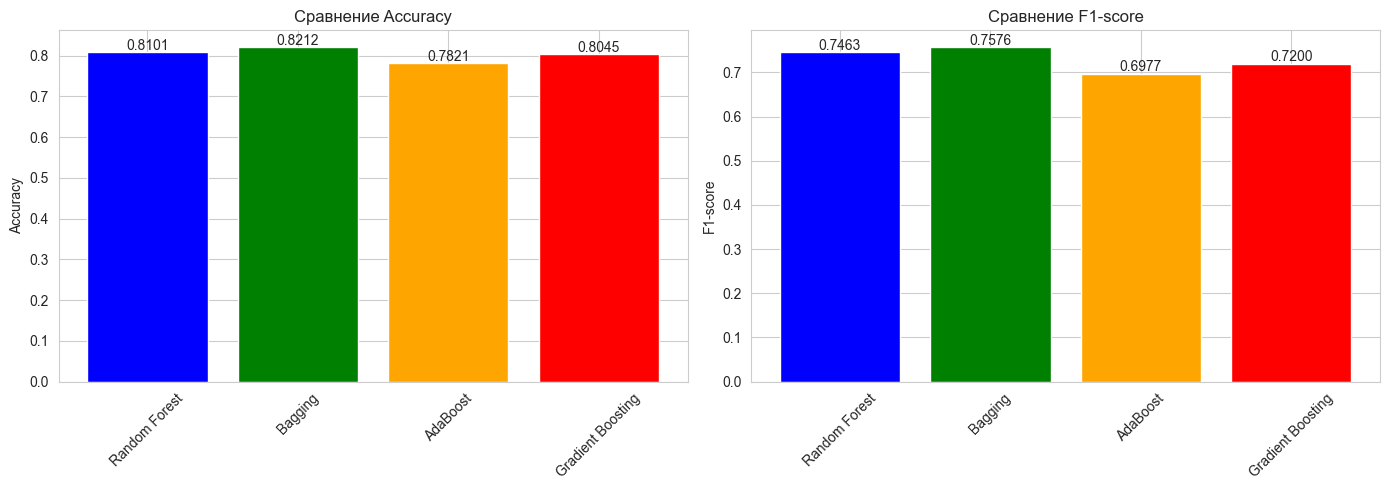

In [10]:
comparison = pd.DataFrame({
    'Модель': ['Random Forest', 'Bagging', 'AdaBoost', 'Gradient Boosting'],
    'Accuracy': [accuracy_rf, accuracy_bag, accuracy_ada, accuracy_gb],
    'F1-score': [f1_rf, f1_bag, f1_ada, f1_gb]
})

print("Сравнение моделей:")
print(comparison.round(4))

best_model = comparison.loc[comparison['F1-score'].idxmax(), 'Модель']
best_f1 = comparison['F1-score'].max()
print(f"\nЛучшая модель по F1-score: {best_model} ({best_f1:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(comparison['Модель'], comparison['Accuracy'], color=['blue', 'green', 'orange', 'red'])
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Сравнение Accuracy')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(comparison['Accuracy']):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center')

axes[1].bar(comparison['Модель'], comparison['F1-score'], color=['blue', 'green', 'orange', 'red'])
axes[1].set_ylabel('F1-score')
axes[1].set_title('Сравнение F1-score')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(comparison['F1-score']):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center')

plt.tight_layout()
plt.show()

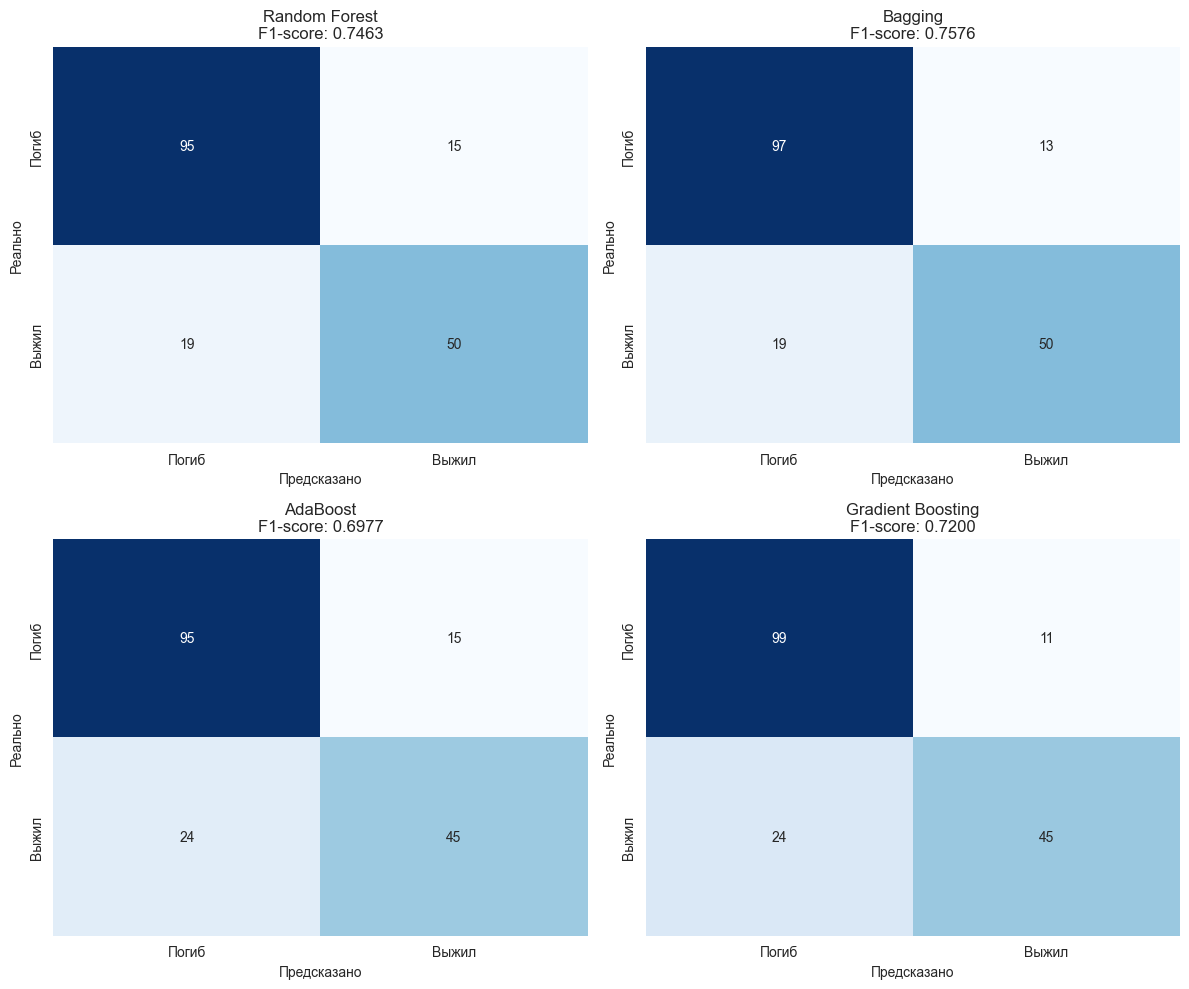

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models = [rf, bagging, ada, gb]
names = ['Random Forest', 'Bagging', 'AdaBoost', 'Gradient Boosting']

for i, (model, name) in enumerate(zip(models, names)):
    row, col = i // 2, i % 2
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[row, col], cmap='Blues', cbar=False)
    axes[row, col].set_title(f'{name}\nF1-score: {f1_score(y_test, y_pred):.4f}')
    axes[row, col].set_xlabel('Предсказано')
    axes[row, col].set_ylabel('Реально')
    axes[row, col].set_xticklabels(['Погиб', 'Выжил'])
    axes[row, col].set_yticklabels(['Погиб', 'Выжил'])

plt.tight_layout()
plt.show()

In [12]:
import time

models_dict = {
    'Random Forest': rf,
    'Bagging': bagging,
    'AdaBoost': ada,
    'Gradient Boosting': gb
}

print("Сравнение времени обучения:")
for name, model in models_dict.items():
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()
    print(f"{name}: {end - start:.3f} сек")

Сравнение времени обучения:
Random Forest: 0.352 сек
Bagging: 0.647 сек
AdaBoost: 0.494 сек
Gradient Boosting: 0.418 сек


In [13]:
print(f"Random Forest - F1: {f1_rf:.4f}")
print(f"Bagging - F1: {f1_bag:.4f}")
print(f"AdaBoost - F1: {f1_ada:.4f}")
print(f"Gradient Boosting - F1: {f1_gb:.4f}")

Random Forest - F1: 0.7463
Bagging - F1: 0.7576
AdaBoost - F1: 0.6977
Gradient Boosting - F1: 0.7200
